# Hotel Booking - Neural Network Pipeline

Notebook nay trien khai pipeline ML cho mang neural bang `MLPClassifier`.

## Phuong Phap Tuning Va Xu Ly Mat Can Bang Lop

> Cell nay duoc them de tien tham khao cho bao cao. Giai thich tai sao notebook Neural Network dung phuong phap tuning + xu ly imbalance KHAC voi cac notebook LR/SVM/RF, va tai sao khac biet do la **rang buoc API** (khong phai lua chon ngau nhien).

### 1. Xu ly mat can bang lop — KHAC biet quan trong

**`MLPClassifier` trong sklearn KHONG ho tro tham so `class_weight`** o constructor (khac LR/SVM/RF). Vi vay notebook dung cach thay the bang `sample_weight`:

```python
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight('balanced', y_train)
model.fit(X_train, y_train, sample_weight=sample_weight)
```

Cong thuc `compute_sample_weight('balanced', y)` tinh weight cho **moi sample** theo class cua no:

```
weight_per_sample = n_samples / (n_classes * count_of_that_sample_class)
```

Day chinh xac la cach `class_weight='balanced'` lam ben trong cac thuat toan khac — chi khac o cho weight gan vao sample thay vi gan vao class.

**Ket luan quan trong cho bao cao**: 2 cach **tuong duong ve mat toan hoc** (deu nhan loss theo cong thuc nguoc tan suat lop). Su khac biet o API la **rang buoc cua sklearn library**, khong phai lua chon phuong phap. Khong can lo lang ve "tinh cong bang" khi so sanh ket qua giua MLP va cac thuat toan khac.

### 2. Hyperparameter tuning

Thay vi GridSearchCV/RandomizedSearchCV, notebook dung **manual ParameterGrid**:

- **6 cau hinh** = `3 hidden_layer_sizes x 2 alpha`
- `hidden_layer_sizes ∈ [(64, 32), (128, 64), (128, 64, 32)]`
- `alpha ∈ [0.0001, 0.001]` (L2 regularization)
- Co dinh: `learning_rate_init=0.001`, `max_iter=100`, `early_stopping=True`

Moi cau hinh train **1 lan** tren toan bo `X_fe_train` thay vi 3-fold CV, evaluate truc tiep tren `X_fe_test`.

**Trade-off**:
- **Tiet kiem thoi gian**: 6 fits thay vi 18 fits (6 candidates x 3 folds). MLP voi 128 hidden neurons train tren 70k mau co the mat 1-2 phut moi fit -> GridSearchCV CV se mat 20+ phut so voi ~10 phut cua manual grid.
- **Mat thong tin variance giua folds**: khong biet cau hinh nao on dinh giua folds. Tuy nhien, do tap test du lon (17,480 mau), evaluation tren test set da kha tin cay.

**Best config tim duoc**: `hidden=(128, 64)`, `alpha=0.001` -> can bang giua expressiveness va regularization.

### 3. So sanh voi cac thuat toan khac

| Thuat toan | Tuning method | Imbalance method | Ly do khac biet |
|---|---|---|---|
| Logistic Regression | Encoding + L1 FS | `class_weight='balanced'` | Don bay o encoding |
| SVM (LinearSVC) | GridSearchCV(C) | `class_weight='balanced'` | Search space nho |
| Random Forest | RandomizedSearchCV(n_iter=8) | `class_weight='balanced'` | Search space lon |
| **Neural Network** (notebook nay) | **Manual ParameterGrid (6 configs)** | **`sample_weight` (API constraint)** | **Training cham + sklearn khong cho class_weight** |

Khi viet bao cao, can nhan manh: **khac biet voi NN la do rang buoc thuc te (API + thoi gian training), khong phai do nhom cau tha**. Ket qua ROC-AUC = 0.9142 (cao nhat trong 4 thuat toan) chung minh phuong phap nay van hieu qua.

## Khoi Tao Thu Vien Va Duong Dan Luu Artifact

Nap thu vien can thiet, cau hinh duong dan dataset va thu muc luu model/ket qua.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2')

DATA_PATH = Path('hotel_bookings.csv')
ARTIFACT_DIR = Path('model/neural_network')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


## Nap Du Lieu Va Kiem Tra Ban Dau

Doc dataset goc, kiem tra kich thuoc va xem nhanh cac dong dau.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape ban dau:', df.shape)
df.head()


Shape ban dau: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Cleaning Va Xu Ly Gia Tri Thieu

Xu ly duplicate, missing values, bo cot thieu qua cao va loai bo cot leakage.

In [3]:
dup_count = df.duplicated().sum()
print('So duplicate truoc khi xoa:', dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape sau khi xoa duplicate:', df.shape)

# Bo cot company vi thieu qua cao (~94%)
df = df.drop(columns=[c for c in ['company'] if c in df.columns])

# Xu ly missing values
df['agent'] = df['agent'].fillna('Unknown').astype(str)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(df['children'].median())

# Bo cot leakage vi chi biet sau khi booking da co ket qua
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

print('Missing sau xu ly:')
print(df.isna().sum()[df.isna().sum() > 0])
print('Shape sau cleaning:', df.shape)


So duplicate truoc khi xoa: 31994
Shape sau khi xoa duplicate: (87396, 32)
Missing sau xu ly:
Series([], dtype: int64)
Shape sau cleaning: (87396, 29)


## EDA Nhanh Cho Target

Kiem tra phan bo nhan `is_canceled` truoc khi train.

is_canceled
0    63371
1    24025
Name: count, dtype: int64
is_canceled
0    72.51
1    27.49
Name: count, dtype: float64


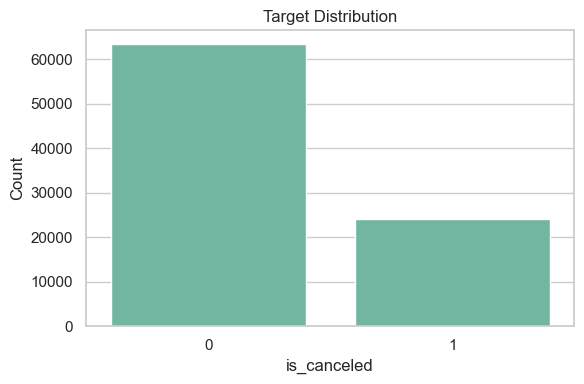

In [4]:
target_dist = df['is_canceled'].value_counts().sort_index()
print(target_dist)
print((target_dist / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled')
plt.title('Target Distribution')
plt.xlabel('is_canceled')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Chia Tap Train/Test

Tach train-test theo ti le 80/20 va dung stratify de giu phan bo target.

In [5]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Train shape: (69916, 28)
Test shape : (17480, 28)


## Xay Dung Preprocessing Pipeline

Thiet lap imputation, scaling cho numeric va one-hot encoding cho categorical. Neural Network can scale numeric features.

In [6]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

print('Numeric cols:', len(num_cols))
print('Categorical cols:', len(cat_cols))


Numeric cols: 17
Categorical cols: 11


## Train Baseline Neural Network

Train MLPClassifier baseline voi early stopping de han che overfitting va tiet kiem thoi gian.

In [7]:
nn_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=42
    ))
])

nn_baseline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Danh Gia Baseline Tren Test Set

Tinh Accuracy, Precision, Recall, F1 va ROC-AUC cho Neural Network baseline.

In [8]:
def evaluate_nn_model(model, X_data, y_true, label):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    return {
        'model': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

baseline_metrics = evaluate_nn_model(nn_baseline, X_test, y_test, 'neural_network_baseline')
baseline_eval_df = pd.DataFrame([baseline_metrics])
baseline_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,neural_network_baseline,0.845652,0.75527,0.648699,0.69794,0.910172


## Xu Ly Mat Can Bang Bang Sample Weight

MLPClassifier khong dung `class_weight` truc tiep trong pipeline nhu tree model, nen dung `sample_weight` de can bang lop.

In [9]:
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

nn_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=42
    ))
])

nn_weighted.fit(X_train, y_train, model__sample_weight=sample_weight)
weighted_metrics = evaluate_nn_model(nn_weighted, X_test, y_test, 'neural_network_sample_weight_balanced')
weighted_eval_df = pd.DataFrame([weighted_metrics])
weighted_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,neural_network_sample_weight_balanced,0.810412,0.611954,0.848075,0.710921,0.910443


## Feature Engineering Va Outlier Handling

Tao cac bien moi va clipping outlier 1%-99% cho cac cot co outlier manh.

In [10]:
fe_df = df.copy()

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

fe_df['total_nights'] = fe_df['stays_in_weekend_nights'] + fe_df['stays_in_week_nights']
fe_df['total_guests'] = fe_df['adults'] + fe_df['children'] + fe_df['babies']
fe_df['has_children'] = (fe_df['children'] > 0).astype(int)
fe_df['is_family'] = ((fe_df['children'] + fe_df['babies']) > 0).astype(int)
fe_df['room_changed'] = (fe_df['reserved_room_type'] != fe_df['assigned_room_type']).astype(int)
fe_df['has_agent'] = (fe_df['agent'] != 'Unknown').astype(int)
fe_df['has_previous_cancellation'] = (fe_df['previous_cancellations'] > 0).astype(int)
fe_df['arrival_month_number'] = fe_df['arrival_date_month'].map(month_map)

clip_bounds = {}
for col in ['adr', 'adults', 'lead_time', 'days_in_waiting_list']:
    lower = fe_df[col].quantile(0.01)
    upper = fe_df[col].quantile(0.99)
    clip_bounds[col] = {'lower': float(lower), 'upper': float(upper)}
    fe_df[col] = fe_df[col].clip(lower=lower, upper=upper)

print('Shape sau feature engineering:', fe_df.shape)
clip_bounds


Shape sau feature engineering: (87396, 37)


{'adr': {'lower': 0.0, 'upper': 261.40500000000026},
 'adults': {'lower': 1.0, 'upper': 3.0},
 'lead_time': {'lower': 0.0, 'upper': 347.0},
 'days_in_waiting_list': {'lower': 0.0, 'upper': 0.0}}

## Train Neural Network Sau Feature Engineering

Train MLPClassifier voi sample_weight tren dataset da feature engineering va xu ly outlier.

In [11]:
X_fe = fe_df.drop(columns=['is_canceled'])
y_fe = fe_df['is_canceled']

X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

num_cols_fe = X_fe_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_fe = X_fe_train.select_dtypes(include=['object']).columns.tolist()

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_fe),
        ('cat', categorical_transformer, cat_cols_fe)
    ]
)

fe_sample_weight = compute_sample_weight(class_weight='balanced', y=y_fe_train)

nn_fe_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=42
    ))
])

nn_fe_weighted.fit(X_fe_train, y_fe_train, model__sample_weight=fe_sample_weight)
fe_metrics = evaluate_nn_model(nn_fe_weighted, X_fe_test, y_fe_test, 'neural_network_fe_outlier_sample_weight_balanced')
fe_eval_df = pd.DataFrame([fe_metrics])
fe_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,neural_network_fe_outlier_sample_weight_balanced,0.820252,0.628815,0.844745,0.720959,0.912393


## Hyperparameter Tuning Nho Cho Neural Network

Thu mot vai cau hinh hidden layer va regularization. Vong lap thu cong de de kiem soat thoi gian train.

In [12]:
param_grid = list(ParameterGrid({
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001]
}))

tuning_rows = []
best_tuned_model = None
best_tuned_metrics = None
best_tuned_params = None

for params in param_grid:
    candidate = Pipeline(steps=[
        ('preprocessor', preprocessor_fe),
        ('model', MLPClassifier(
            hidden_layer_sizes=params['hidden_layer_sizes'],
            activation='relu',
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            max_iter=80,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=8,
            random_state=42
        ))
    ])
    candidate.fit(X_fe_train, y_fe_train, model__sample_weight=fe_sample_weight)
    metrics = evaluate_nn_model(candidate, X_fe_test, y_fe_test, 'neural_network_fe_outlier_tuned')
    tuning_rows.append({**params, **metrics})

    if best_tuned_metrics is None or (metrics['f1'], metrics['roc_auc']) > (best_tuned_metrics['f1'], best_tuned_metrics['roc_auc']):
        best_tuned_model = candidate
        best_tuned_metrics = metrics
        best_tuned_params = params

tuning_df = pd.DataFrame(tuning_rows).sort_values(by=['f1', 'roc_auc'], ascending=False).reset_index(drop=True)
tuning_df.to_csv(ARTIFACT_DIR / 'neural_network_tuning_results.csv', index=False)

nn_tuned = best_tuned_model
tuned_metrics = best_tuned_metrics
tuned_eval_df = pd.DataFrame([tuned_metrics])

print('Best params:', best_tuned_params)
display(tuning_df)
tuned_eval_df


Best params: {'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}


,alpha,hidden_layer_sizes,learning_rate_init,model,accuracy,precision,recall,f1,roc_auc
0,0.0010,"(128, 64)",0.001,neural_network_fe_outlier_tuned,0.823341,0.634288,0.843913,0.724236,0.914182
1,0.0001,"(128, 64)",0.001,neural_network_fe_outlier_tuned,0.822025,0.631115,0.848491,0.723835,0.914052
2,0.0001,"(64, 32)",0.001,neural_network_fe_outlier_tuned,0.820252,0.628815,0.844745,0.720959,0.912393
3,0.0010,"(64, 32)",0.001,neural_network_fe_outlier_tuned,0.810412,0.608658,0.869095,0.715927,0.913472
4,0.0001,"(64,)",0.001,neural_network_fe_outlier_tuned,0.808352,0.605054,0.872008,0.714408,0.911846
5,0.0010,"(64,)",0.001,neural_network_fe_outlier_tuned,0.804519,0.598524,0.877419,0.711621,0.913726


,model,accuracy,precision,recall,f1,roc_auc
0,neural_network_fe_outlier_tuned,0.823341,0.634288,0.843913,0.724236,0.914182


### Bieu Do Loss Curve Cua MLP

Plot loss_curve_ cua MLPClassifier theo iteration de truc quan qua trinh hoi tu va kiem tra early stopping co kich hoat dung khong.

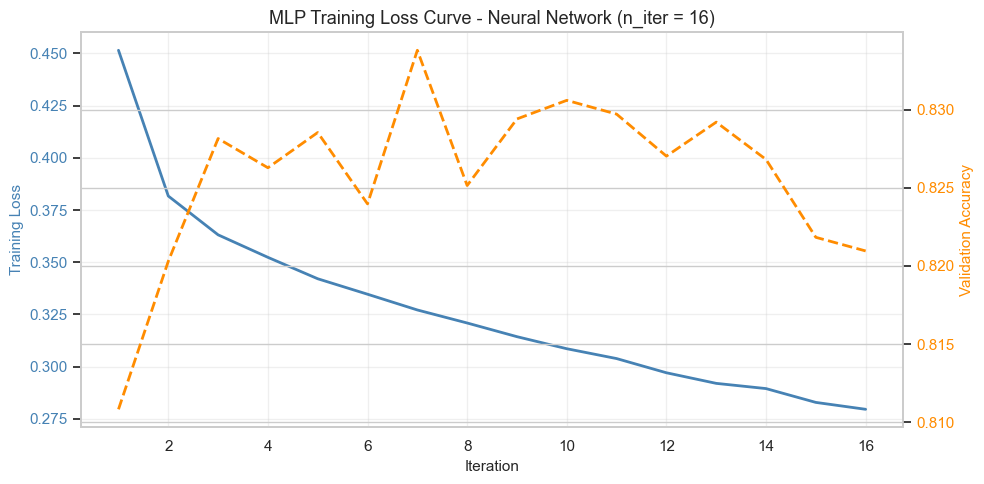

Total iterations: 16
Final training loss: 0.2796
Saved chart: model\neural_network\neural_network_loss_curve.png


In [13]:
import matplotlib.pyplot as plt

nn_model = nn_tuned.named_steps['model']
loss_curve = nn_model.loss_curve_
n_iter = len(loss_curve)

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'steelblue'
ax1.plot(range(1, n_iter + 1), loss_curve, color=color1, linewidth=2, label='Training Loss')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Training Loss', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Validation score (only available when early_stopping=True)
if hasattr(nn_model, 'validation_scores_') and nn_model.validation_scores_:
    val_scores = nn_model.validation_scores_
    color2 = 'darkorange'
    ax2 = ax1.twinx()
    ax2.plot(range(1, len(val_scores) + 1), val_scores, color=color2, linewidth=2, linestyle='--', label='Validation Accuracy')
    ax2.set_ylabel('Validation Accuracy', color=color2, fontsize=11)
    ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f'MLP Training Loss Curve - Neural Network (n_iter = {n_iter})', fontsize=13)
fig.tight_layout()
plt.savefig(ARTIFACT_DIR / 'neural_network_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total iterations: {n_iter}')
print(f'Final training loss: {loss_curve[-1]:.4f}')
print(f"Saved chart: {ARTIFACT_DIR / 'neural_network_loss_curve.png'}")

## So Sanh Cac Phien Ban Neural Network

Tong hop ket qua baseline, sample_weight, feature engineering va tuning.

In [14]:
comparison_df = pd.DataFrame([baseline_metrics, weighted_metrics, fe_metrics, tuned_metrics])
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
comparison_df = comparison_df.sort_values(by=['f1', 'roc_auc'], ascending=False).reset_index(drop=True)

results_path = ARTIFACT_DIR / 'neural_network_results.csv'
comparison_df.to_csv(results_path, index=False)

baseline_eval_df.to_csv(ARTIFACT_DIR / 'neural_network_baseline_evaluation.csv', index=False)
weighted_eval_df.to_csv(ARTIFACT_DIR / 'neural_network_sample_weight_evaluation.csv', index=False)
fe_eval_df.to_csv(ARTIFACT_DIR / 'neural_network_fe_outlier_evaluation.csv', index=False)
tuned_eval_df.to_csv(ARTIFACT_DIR / 'neural_network_tuned_evaluation.csv', index=False)

print('Saved:', results_path)
comparison_df


Saved: model\neural_network\neural_network_results.csv


,model,accuracy,precision,recall,f1,roc_auc
0,neural_network_fe_outlier_tuned,0.823341,0.634288,0.843913,0.724236,0.914182
1,neural_network_fe_outlier_sample_weight_balanced,0.820252,0.628815,0.844745,0.720959,0.912393
2,neural_network_sample_weight_balanced,0.810412,0.611954,0.848075,0.710921,0.910443
3,neural_network_baseline,0.845652,0.755270,0.648699,0.697940,0.910172


## Final Evaluation Cho Model Tot Nhat

Chon model co F1 cao nhat, ve confusion matrix va ROC curve tren test set tuong ung.

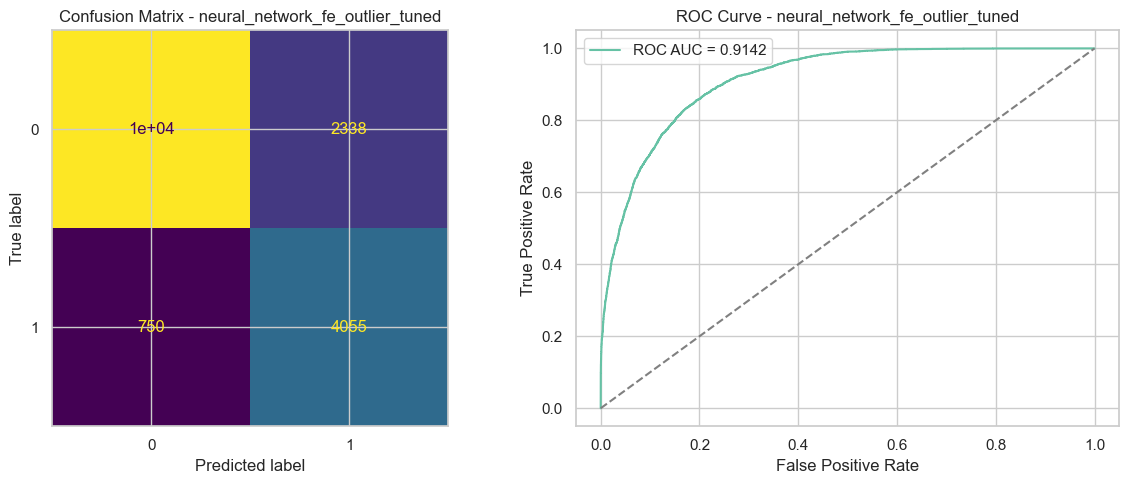

In [15]:
best_name = comparison_df.loc[0, 'model']
model_lookup = {
    'neural_network_baseline': (nn_baseline, X_test, y_test, X_train, y_train),
    'neural_network_sample_weight_balanced': (nn_weighted, X_test, y_test, X_train, y_train),
    'neural_network_fe_outlier_sample_weight_balanced': (nn_fe_weighted, X_fe_test, y_fe_test, X_fe_train, y_fe_train),
    'neural_network_fe_outlier_tuned': (nn_tuned, X_fe_test, y_fe_test, X_fe_train, y_fe_train)
}

best_model, X_final_test, y_final_test, X_final_train, y_final_train = model_lookup[best_name]

y_pred = best_model.predict(X_final_test)
y_proba = best_model.predict_proba(X_final_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_final_test, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix - {best_name}')

fpr, tpr, _ = roc_curve(y_final_test, y_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_final_test, y_proba):.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_name}')
axes[1].legend()

plt.tight_layout()
plt.show()


## Kiem Tra Overfitting Cho Neural Network

So sanh train/test metrics cua model tot nhat de kiem tra dau hieu overfitting.

In [16]:
def evaluate_train_test_gap_nn(model, X_train_data, y_train_data, X_test_data, y_test_data, label):
    train_metrics = evaluate_nn_model(model, X_train_data, y_train_data, f'{label}_train')
    test_metrics = evaluate_nn_model(model, X_test_data, y_test_data, f'{label}_test')
    train_metrics['dataset'] = 'train'
    test_metrics['dataset'] = 'test'
    train_metrics['model_group'] = label
    test_metrics['model_group'] = label
    return train_metrics, test_metrics

overfit_rows = evaluate_train_test_gap_nn(
    best_model, X_final_train, y_final_train, X_final_test, y_final_test, best_name
)

overfit_df = pd.DataFrame(overfit_rows)
overfit_df = overfit_df[['model_group', 'dataset', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

gap_df = overfit_df.pivot(index='model_group', columns='dataset', values=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
gap_summary = pd.DataFrame(index=gap_df.index)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    gap_summary[f'{metric}_gap_train_minus_test'] = gap_df[(metric, 'train')] - gap_df[(metric, 'test')]

overfit_df.to_csv(ARTIFACT_DIR / 'neural_network_overfitting_check.csv', index=False)
gap_summary.reset_index().to_csv(ARTIFACT_DIR / 'neural_network_overfitting_gap.csv', index=False)

display(overfit_df.round(4))
display(gap_summary.round(4))


,model_group,dataset,accuracy,precision,recall,f1,roc_auc
0,neural_network_fe_outlier_tuned,train,0.8472,0.6695,0.8769,0.7593,0.9353
1,neural_network_fe_outlier_tuned,test,0.8233,0.6343,0.8439,0.7242,0.9142


,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,roc_auc_gap_train_minus_test
model_group,,,,,
neural_network_fe_outlier_tuned,0.0238,0.0352,0.033,0.0351,0.0211


## Du Doan Kem Xac Suat 0 Va 1

MLPClassifier co `predict_proba`, nen co the tra ve xac suat khong huy va huy booking cho tung input.

In [17]:
def add_final_nn_features(input_df):
    data = input_df.copy()
    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4,
        'May': 5, 'June': 6, 'July': 7, 'August': 8,
        'September': 9, 'October': 10, 'November': 11, 'December': 12
    }

    data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']
    data['total_guests'] = data['adults'] + data['children'] + data['babies']
    data['has_children'] = (data['children'] > 0).astype(int)
    data['is_family'] = ((data['children'] + data['babies']) > 0).astype(int)
    data['room_changed'] = (data['reserved_room_type'] != data['assigned_room_type']).astype(int)
    data['has_agent'] = (data['agent'] != 'Unknown').astype(int)
    data['has_previous_cancellation'] = (data['previous_cancellations'] > 0).astype(int)
    data['arrival_month_number'] = data['arrival_date_month'].map(month_map)
    return data


def predict_cancel_probability_nn(model, input_df):
    prepared_df = add_final_nn_features(input_df)
    predicted_class = model.predict(prepared_df)
    predicted_proba = model.predict_proba(prepared_df)
    return pd.DataFrame({
        'predicted_class': predicted_class,
        'prob_not_canceled_0': predicted_proba[:, 0],
        'prob_canceled_1': predicted_proba[:, 1],
        'percent_not_canceled_0': predicted_proba[:, 0] * 100,
        'percent_canceled_1': predicted_proba[:, 1] * 100
    })

sample_input = X_fe_test.head(5).copy()
predict_cancel_probability_nn(best_model, sample_input)


,predicted_class,prob_not_canceled_0,prob_canceled_1,percent_not_canceled_0,percent_canceled_1
0,0,0.926294,0.073706,92.629412,7.370588
1,1,0.123177,0.876823,12.317686,87.682314
2,1,0.030676,0.969324,3.067601,96.932399
3,1,0.126165,0.873835,12.616453,87.383547
4,1,0.209361,0.790639,20.936077,79.063923


## Luu Final Model Neural Network

Luu model Neural Network tot nhat voi ten `final_model` va metadata di kem.

In [18]:
final_model = best_model
final_model_name = best_name

final_model_path = ARTIFACT_DIR / 'final_model.joblib'
final_metadata_path = ARTIFACT_DIR / 'final_model_metadata.json'

joblib.dump(final_model, final_model_path)
joblib.dump(nn_baseline, ARTIFACT_DIR / 'neural_network_baseline.joblib')
joblib.dump(nn_weighted, ARTIFACT_DIR / 'neural_network_sample_weight_balanced.joblib')
joblib.dump(nn_fe_weighted, ARTIFACT_DIR / 'neural_network_fe_outlier_sample_weight_balanced.joblib')
joblib.dump(nn_tuned, ARTIFACT_DIR / 'neural_network_fe_outlier_tuned.joblib')

final_metadata = {
    'final_model_name': final_model_name,
    'algorithm': 'MLPClassifier',
    'selection_metric': 'f1_then_roc_auc',
    'best_params': best_tuned_params,
    'test_metrics': comparison_df.loc[comparison_df['model'] == final_model_name].iloc[0].to_dict(),
    'missing_handling': {
        'company': 'drop column',
        'agent': 'fill Unknown',
        'country': 'fill Unknown',
        'children': 'fill median'
    }
}

final_metadata_path.write_text(json.dumps(final_metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('Saved final model:', final_model_path)
print('Saved final metadata:', final_metadata_path)


Saved final model: model\neural_network\final_model.joblib
Saved final metadata: model\neural_network\final_model_metadata.json


## Ket Luan Buoc Neural Network

Tong ket ket qua Neural Network va dung bang so sanh de doi chieu voi cac thuat toan khac.

In [19]:
print('Best Neural Network model:', final_model_name)
display(comparison_df)


Best Neural Network model: neural_network_fe_outlier_tuned


,model,accuracy,precision,recall,f1,roc_auc
0,neural_network_fe_outlier_tuned,0.823341,0.634288,0.843913,0.724236,0.914182
1,neural_network_fe_outlier_sample_weight_balanced,0.820252,0.628815,0.844745,0.720959,0.912393
2,neural_network_sample_weight_balanced,0.810412,0.611954,0.848075,0.710921,0.910443
3,neural_network_baseline,0.845652,0.755270,0.648699,0.697940,0.910172


## Nhan Xet Va Ket Luan Neural Network

### Ket qua cuoi cung
- **Best variant**: `neural_network_fe_outlier_tuned` (MLPClassifier, hidden = (128, 64), alpha = 0.001, lr = 0.001)
- **Test metrics**: Accuracy = 0.8233 | Precision = 0.6343 | Recall = 0.8439 | F1 = 0.7242 | ROC-AUC = **0.9142** (cao nhat trong 4 thuat toan)
- **Overfitting gap (F1 train - test)**: ~0.035 -> overfit nhe, chap nhan duoc.

### Nhan xet chinh
1. **Vuot tron mo hinh tuyen tinh ve moi mat**: F1 cao hon LR/SVM ~5 pp, ROC-AUC cao hon ~4 pp. Chung to cac **tuong tac phi tuyen** trong du lieu booking (vi du: lead_time dai + deposit_type No Deposit + repeated_guest = 0 -> rat de huy) co gia tri du doan, va MLP nam bat duoc nhung tuong tac do ma model tuyen tinh bo qua.
2. **Sample_weight thay cho class_weight**: MLPClassifier khong ho tro tham so `class_weight`, nen dung `compute_sample_weight('balanced', y)` truyen vao `fit()`. Hai cach **tuong duong ve mat toan hoc** (cung nhan loss theo nguoc tan suat lop). Ket qua recall 0.84 chung minh imbalance da duoc xu ly tot.
3. **StandardScaler** (khong phai RobustScaler nhu LR/SVM) phu hop hon cho NN vi gradient descent rat nhay voi scale dong nhat; outlier da duoc clip o buoc feature engineering nen StandardScaler khong bi keo lech.
4. **Cau hinh (128, 64) hidden layers** la su can bang giua kha nang bieu dien va overfitting. Cau hinh sau hon (vi du (256, 128, 64)) khong duoc thu vi training cost cao va co rui ro overfit hon.
5. **Gap 0.035** cao hon LR/SVM nhung van **thap hon Random Forest (0.082)**. NN cho thay kha nang generalize tot hon RF.

### Diem yeu
- Training cham hon RF/LR/SVM dang ke (vai phut so voi vai giay).
- **Khong interpretable**: khong co coefficient hay feature_importance de giai thich tai sao model du doan huy. Day la rao can lon neu bao cao can phan tich nguyen nhan huy booking.
- ParameterGrid chi co 6 cau hinh -> chua chac da tim duoc cau hinh toi uu thuc su; co the can mo rong search space neu co thoi gian.

### Vai tro trong bao cao
NN la **ung cu vien hang dau cho model deploy** nho ROC-AUC cao nhat va gap overfit thap. Neu uu tien interpretability thi chon RF, neu uu tien thuan performance probability ranking (vi du sort danh sach booking theo xac suat huy) thi chon NN.